In [35]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
results_path = REPO_ROOT / "results"
sys.path.insert(0, str(REPO_ROOT))

from pathlib import Path
import os

print("results_path:", results_path)
print("results_path absolute:", Path(results_path).resolve())

print("\nresults_dict:")
for method_label, method_path in results_dict.items():
    path = Path(results_path) / method_path
    print(f"\n{method_label!r}")
    print(f"  method_path: {method_path!r}")
    print(f"  resolved:    {path.resolve()}")
    print(f"  exists:      {path.exists()}")
    print(f"  is_dir:      {path.is_dir()}")

    if path.exists():
        print("  contents:")
        for item in list(path.iterdir())[:10]:
            print("   ", item.name)

from src.toolkit.process_results import extract_results
from src.toolkit.post_metrics import compute_forgetting, compute_average, compute_average_forgetting, compute_AAA, compute_mean_std_metric, compute_wcacc, decorate_with_training_task
import seaborn as sns
import matplotlib.pyplot as plt
import os
plt.style.use("matplotlibrc.template")
colors = plt.cm.Dark2.colors

results_path: /home/kobros-tech/workspace/AI/ocl_survey/results
results_path absolute: /home/kobros-tech/workspace/AI/ocl_survey/results

results_dict:

'ER'
  method_path: 'er_split_cifar100_20_2000'
  resolved:    /home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000
  exists:      True
  is_dir:      True
  contents:
    2
    3
    4
    0
    1

'$\\operatorname{ER-ACE}$'
  method_path: 'er_ace_split_cifar100_20_2000'
  resolved:    /home/kobros-tech/workspace/AI/ocl_survey/results/er_ace_split_cifar100_20_2000
  exists:      False
  is_dir:      False

'DER++'
  method_path: 'der_split_cifar100_20_2000'
  resolved:    /home/kobros-tech/workspace/AI/ocl_survey/results/der_split_cifar100_20_2000
  exists:      False
  is_dir:      False

'MIR'
  method_path: 'mir_split_cifar100_20_2000'
  resolved:    /home/kobros-tech/workspace/AI/ocl_survey/results/mir_split_cifar100_20_2000
  exists:      False
  is_dir:      False

'ER + LwF'
  method_path: 'er_lwf_split_c

In [36]:
def create_results_dict(benchmark, memory_size, include_gdumb=False):
    results_dict = {"ER": f"er_{benchmark}_20_{memory_size}", 
                "$\operatorname{ER-ACE}$":  f"er_ace_{benchmark}_20_{memory_size}",
                "DER++":  f"der_{benchmark}_20_{memory_size}",
                "MIR":  f"mir_{benchmark}_20_{memory_size}",
                "ER + LwF":  f"er_lwf_{benchmark}_20_{memory_size}",
                #"AGEM":  f"agem_{benchmark}_20_{memory_size}",
                "RAR":  f"rar_{benchmark}_20_{memory_size}",
                "SCR":  f"scr_{benchmark}_20_{memory_size}",
                "i.i.d":  f"er_{benchmark}_1_{memory_size}",
                }
    
    if include_gdumb:
        results_dict["GDumb"] = f"gdumb_{benchmark}_20_{memory_size}"
        
    return results_dict

In [37]:
results_path = "ENTER RESULTS PATH HERE"
memory_size = 2000
benchmark = "split_cifar100"
results_dict = {"ER": f"er_{benchmark}_20_{memory_size}", 
                "$\operatorname{ER-ACE}$":  f"er_ace_{benchmark}_20_{memory_size}",
                "DER++":  f"der_{benchmark}_20_{memory_size}",
                "MIR":  f"mir_{benchmark}_20_{memory_size}",
                "ER + LwF":  f"er_lwf_{benchmark}_20_{memory_size}",
                #"AGEM":  f"agem_{benchmark}_20_{memory_size}",
                "RAR":  f"rar_{benchmark}_20_{memory_size}",
                "SCR":  f"scr_{benchmark}_20_{memory_size}",
                #"GDumb":  f"gdumb_{benchmark}_20_{memory_size}",
                "i.i.d":  f"er_{benchmark}_1_{memory_size}",
                }
print(results_dict)

{'ER': 'er_split_cifar100_20_2000', '$\\operatorname{ER-ACE}$': 'er_ace_split_cifar100_20_2000', 'DER++': 'der_split_cifar100_20_2000', 'MIR': 'mir_split_cifar100_20_2000', 'ER + LwF': 'er_lwf_split_cifar100_20_2000', 'RAR': 'rar_split_cifar100_20_2000', 'SCR': 'scr_split_cifar100_20_2000', 'i.i.d': 'er_split_cifar100_1_2000'}


# Adjusted Acc curve

/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er

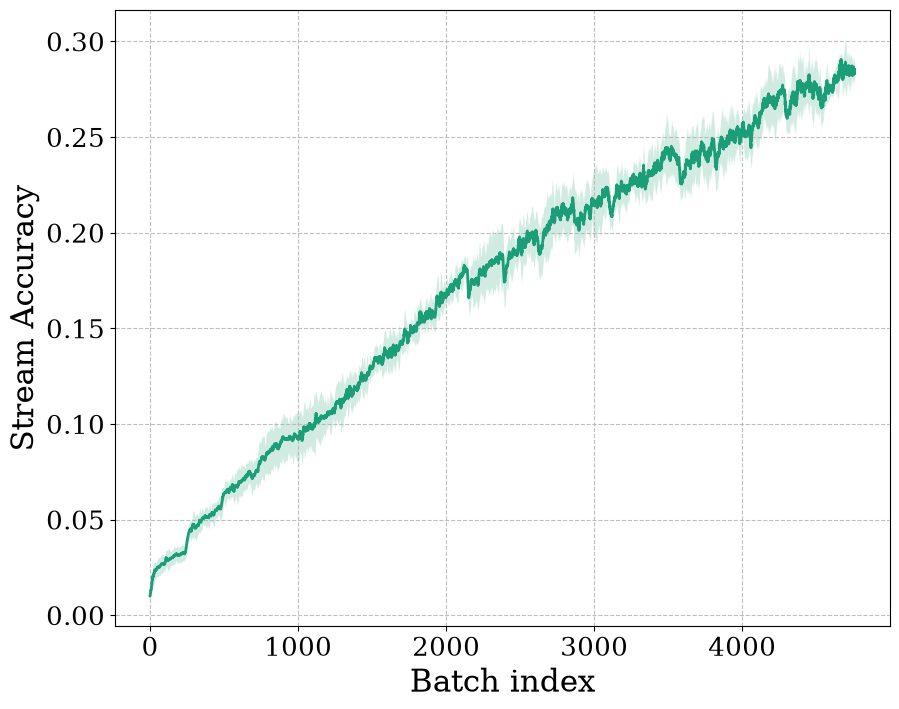

In [48]:
%matplotlib inline

results_path = REPO_ROOT / "results"

for i, (method_label, method_path) in enumerate(results_dict.items()):
    frames_method = extract_results(os.path.join(results_path, method_path))   

    df = frames_method.get("continual")
    if df is not None:
        if method_label != "i.i.d":
            metric_list = [
                f"Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp{i:03d}"
                for i in range(20)
            ]
            df["training_exp"] = df[metric_list].count(axis=1)
            df["StreamAcc"] = (
                df["Top1_Acc_Stream/eval_phase/valid_stream/Task000"]
                * df["training_exp"]
                / 20
            )
        else:
            df["StreamAcc"] = df["Top1_Acc_Stream/eval_phase/valid_stream/Task000"]
    
        df["smoothed_StreamAcc"] = (
            df.groupby("seed")["StreamAcc"]
            .rolling(10, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
    
        sns.lineplot(
            data=df, x="mb_index", y="smoothed_StreamAcc", errorbar="sd", color=colors[i]
        )
        
plt.xlabel("Batch index")
plt.ylabel("Stream Accuracy")
frames_method = extract_results(
    os.path.join(results_path, "er_split_cifar100_20_2000")
)


# Forgetting Figures

/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er

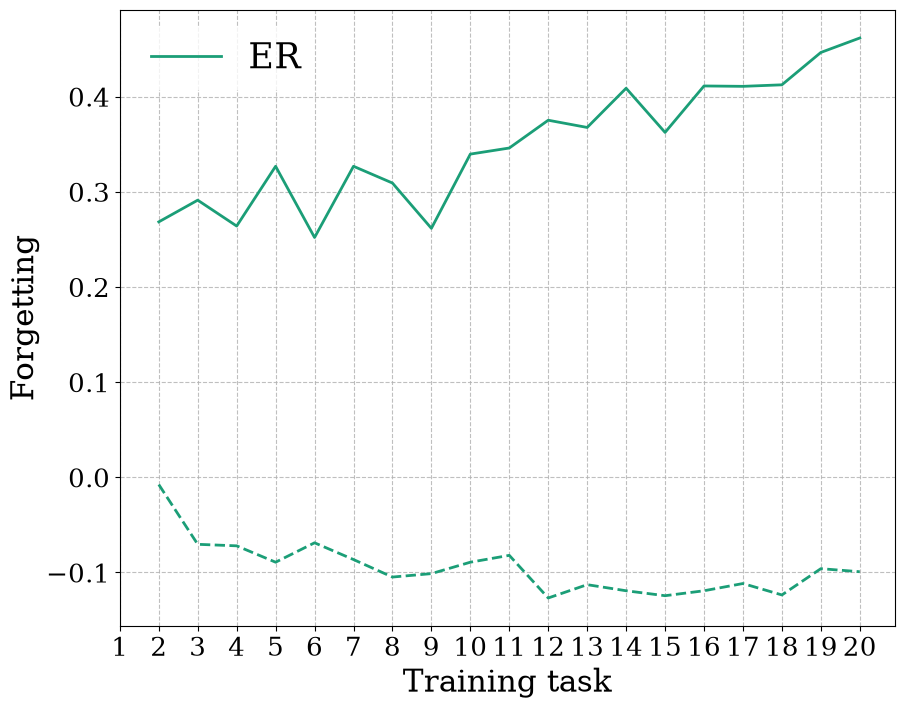

In [51]:
# Forgetting (on normal stream)

for i, (method_label, method_path) in enumerate(results_dict.items()):
    if method_label == "i.i.d": continue
    
    frames = extract_results(os.path.join(results_path, method_path))

    if frames.get("training") is not None:
        df = compute_average_forgetting(
            frames["training"],
            20,
            base_name="Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp")
        
        sns.lineplot(
            data=df,
            x="training_exp",
            y="Average_Forgetting",
            errorbar=None,
            label=method_label,
            color=colors[i])
        
        df = compute_average_forgetting(
            frames["training"],
            20,
            base_name="CumulativeAccuracy/eval_phase/test_stream/Exp",
            name="Average_Cumulative_Forgetting")
        
        sns.lineplot(
            data=df,
            x="training_exp",
            y="Average_Cumulative_Forgetting",
            errorbar=None,
            color=colors[i],
            linestyle="--")

plt.xlabel("Training task")
plt.ylabel("Forgetting")
plt.gca().set_xticks(list(range(1, 21)))

# Task shift figure

/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er

/tmp/ipykernel_7471/2216552313.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"smoothed_{key1}"] = (
/tmp/ipykernel_7471/2216552313.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"smoothed_{key2}"] = (


Text(0, 0.5, 'Task accuracy')

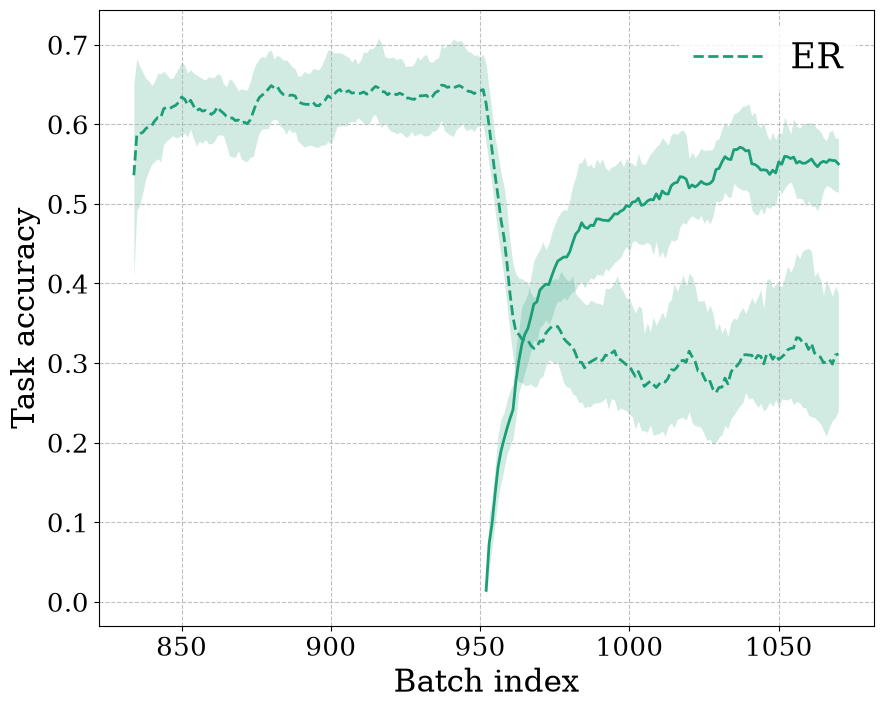

In [53]:

for i, (method_label, method_path) in enumerate(results_dict.items()):
    if method_label not in ["ER", "SCR"]: continue
    
    frames = extract_results(os.path.join(results_path, method_path))
    
    df = frames.get("continual")
    if df is not None:
        step1 = 238*4
        df = df[(df.mb_index > step1 - 238//2) & (df.mb_index < step1 + 238//2)]
        
        key1 = "Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp003"
        key2 = "Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp004"
        
        df[f"smoothed_{key1}"] = (
            df.groupby("seed")[key1]
            .rolling(10, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
        
           
        df[f"smoothed_{key2}"] = (
            df.groupby("seed")[key2]
            .rolling(10, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
        
        sns.lineplot(data=df, x="mb_index", y=f"smoothed_{key1}", label=method_label, color=colors[i], linestyle="--")
        sns.lineplot(data=df, x="mb_index", y=f"smoothed_{key2}", color=colors[i])
        
    
    
    
plt.xlabel("Batch index")
plt.ylabel("Task accuracy")

# Cumulative Accuracy figure

/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er

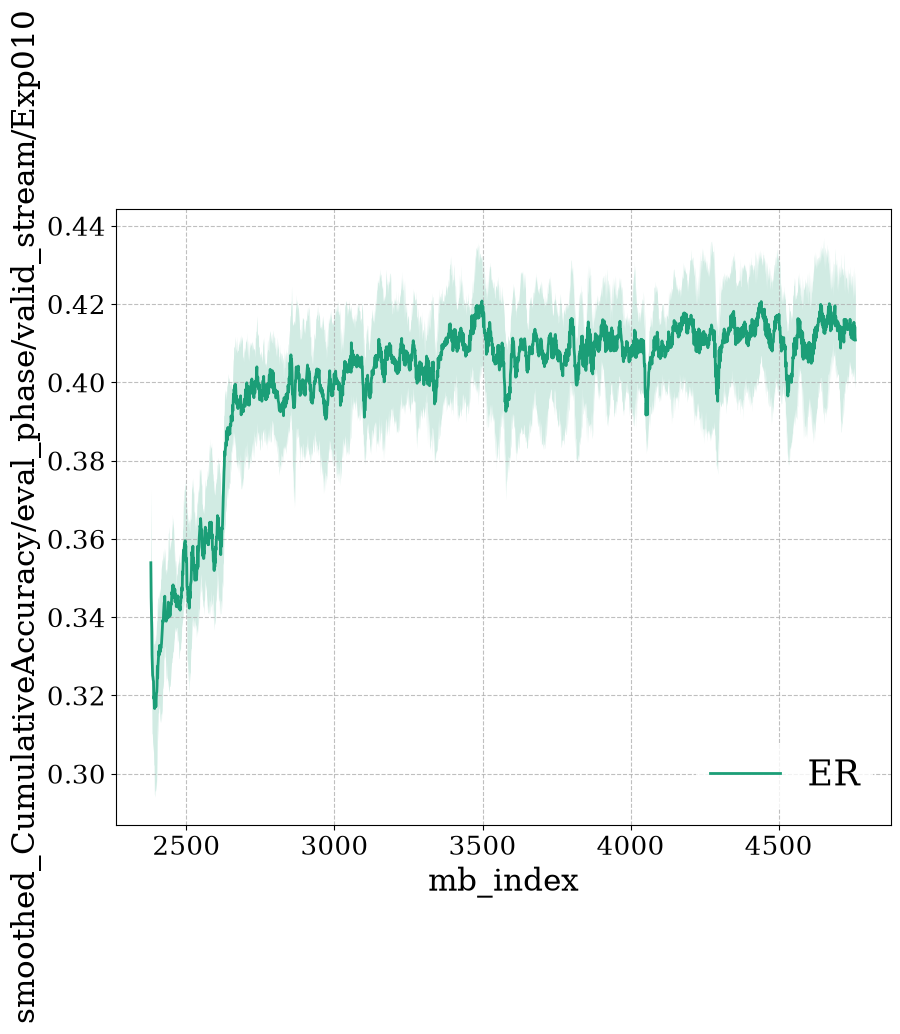

In [55]:

for i, (method_label, method_path) in enumerate(results_dict.items()):
    if method_label not in ["ER", "SCR"]: continue
    
    frames = extract_results(os.path.join(results_path, method_path))
    
    df = frames.get("continual")
    
    if df is not None:
        key = "CumulativeAccuracy/eval_phase/valid_stream/Exp010"
        
        df[f"smoothed_{key}"] = (
            df.groupby("seed")[key]
            .rolling(10, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
       
        sns.lineplot(data=df, x="mb_index", y=f"smoothed_{key}", label=method_label, color=colors[i])
    

# Multiple memory sizes

In [57]:
from collections import defaultdict

filtered_methods = ["ER", "i.i.d", "GDumb"]

# means : {"method-name": [mean_mem_1, mean_mem_2, ...]}
means, stds = defaultdict(list), defaultdict(list)

memory_sizes = [500, 2000, 8000]

for memory_size in memory_sizes:
    results_dict = create_results_dict(benchmark, memory_size, include_gdumb=True)
    for method in filtered_methods:
        frame = extract_results(os.path.join(results_path, results_dict[method])).get("training")
        if frame is not None:
            mean, std = compute_mean_std_metric(frame, "Top1_Acc_Stream/eval_phase/test_stream/Task000")
            means[method].append(mean)
            stds[method].append(std)


/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/2/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/3/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs.json
training
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/logs_continual.json
continual
/home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000/4/linear_probing/logs.json
probing
/home/kobros-tech/workspace/AI/ocl_survey/results/er

ER means: 1 stds: 1 means: [np.float64(0.2815)] stds: [np.float64(0.012223133804389125)]
i.i.d means: 0 stds: 0 means: [] stds: []
GDumb means: 0 stds: 0 means: [] stds: []
Skipping i.i.d: no results
Skipping GDumb: no results


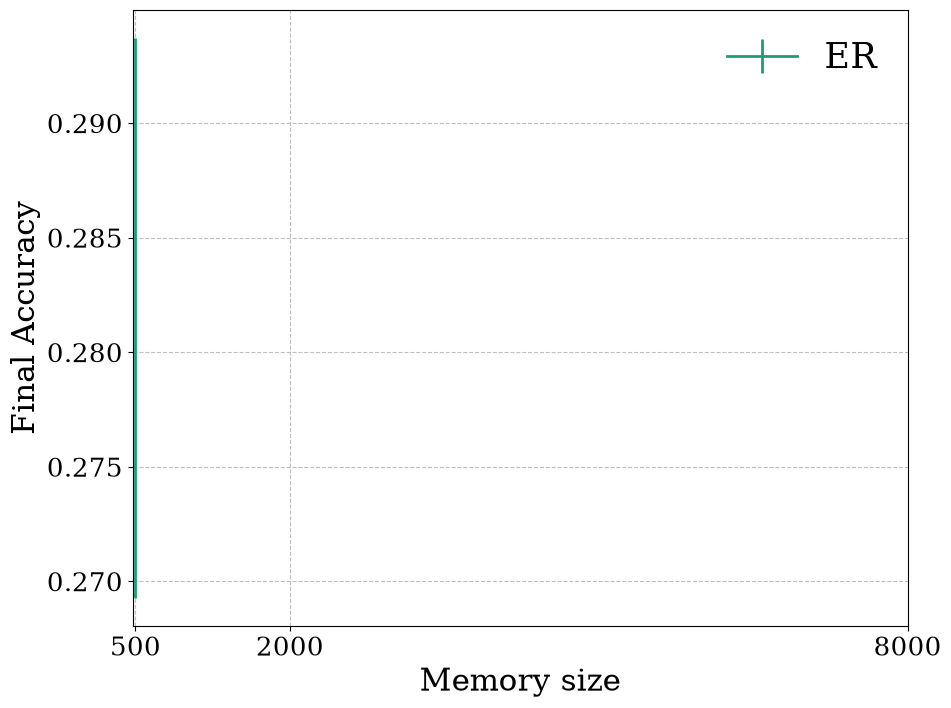

In [63]:
for method in filtered_methods:
    print(
        method,
        "means:", len(means[method]),
        "stds:", len(stds[method]),
        "means:", means[method],
        "stds:", stds[method],
    )

method_colors = {"ER": 0, "i.i.d": 7, "GDumb": 5}

for method in filtered_methods:
    n = len(means[method])

    if n == 0:
        print(f"Skipping {method}: no results")
        continue

    xs = memory_sizes[:n]

    plt.errorbar(
        x=xs,
        y=means[method],
        yerr=stds[method],
        color=colors[method_colors[method]],
        label=method,
    )

plt.legend()
plt.xlabel("Memory size")
plt.ylabel("Final Accuracy")
plt.gca().set_xticks(memory_sizes)

# Joined Adjusted Acc

Skipping ER: no continual results in /DATA/ocl_survey/results_server/er_split_cifar100_20_2000
Skipping $\operatorname{ER-ACE}$: no continual results in /DATA/ocl_survey/results_server/er_ace_split_cifar100_20_2000
Skipping DER++: no continual results in /DATA/ocl_survey/results_server/der_split_cifar100_20_2000
Skipping MIR: no continual results in /DATA/ocl_survey/results_server/mir_split_cifar100_20_2000
Skipping ER + LwF: no continual results in /DATA/ocl_survey/results_server/er_lwf_split_cifar100_20_2000
Skipping RAR: no continual results in /DATA/ocl_survey/results_server/rar_split_cifar100_20_2000
Skipping SCR: no continual results in /DATA/ocl_survey/results_server/scr_split_cifar100_20_2000
Skipping i.i.d: no continual results in /DATA/ocl_survey/results_server/er_split_cifar100_1_2000
Skipping ER: no continual results in /DATA/ocl_survey/results_server/er_split_tinyimagenet_20_4000
Skipping $\operatorname{ER-ACE}$: no continual results in /DATA/ocl_survey/results_server/er_a

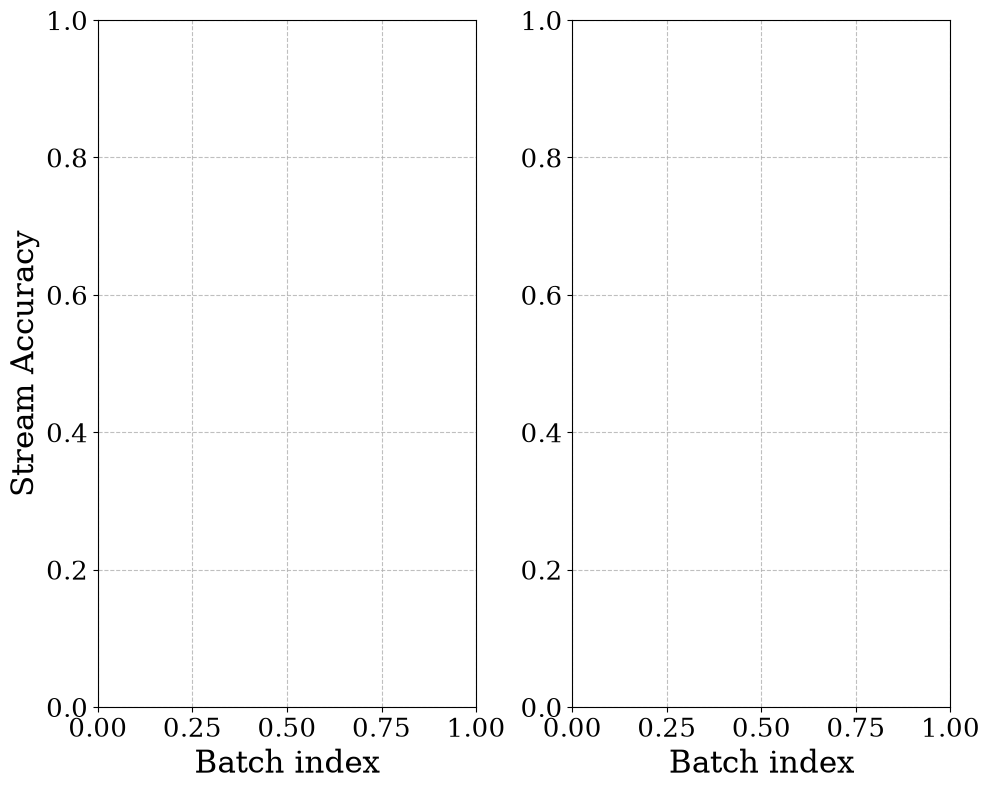

In [69]:
results_dict = create_results_dict("split_cifar100", 2000)

fig, axes = plt.subplots(1, 2)

for method_idx, (method_label, method_path) in enumerate(results_dict.items()):
    result_path = os.path.join(results_path, method_path)
    frames_method = extract_results(result_path)

    if "continual" not in frames_method:
        print(f"Skipping {method_label}: no continual results in {result_path}")
        continue

    df = frames_method["continual"].copy()

    if method_label != "i.i.d":
        metric_list = [
            f"Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp{exp_idx:03d}"
            for exp_idx in range(20)
        ]

        # Only use metrics that actually exist in this result.
        metric_list = [col for col in metric_list if col in df.columns]

        if metric_list:
            df["training_exp"] = df[metric_list].count(axis=1)
            df["StreamAcc"] = (
                df["Top1_Acc_Stream/eval_phase/valid_stream/Task000"]
                * df["training_exp"]
                / 20
            )
        else:
            print(f"Skipping {method_label}: no per-task accuracy metrics")
            continue
    else:
        df["StreamAcc"] = df[
            "Top1_Acc_Stream/eval_phase/valid_stream/Task000"
        ]

    df["smoothed_StreamAcc"] = (
        df.groupby("seed")["StreamAcc"]
        .rolling(10, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    sns.lineplot(
        data=df,
        x="mb_index",
        y="smoothed_StreamAcc",
        errorbar="sd",
        color=colors[method_idx],
        ax=axes[0],
    )

axes[0].set_xlabel("Batch index")
axes[0].set_ylabel("Stream Accuracy")


# TinyImageNet
results_dict = create_results_dict("split_tinyimagenet", 4000)
results_path = "/DATA/ocl_survey/results_server/"

for method_idx, (method_label, method_path) in enumerate(results_dict.items()):
    result_path = os.path.join(results_path, method_path)
    frames_method = extract_results(result_path)

    if "continual" not in frames_method:
        print(f"Skipping {method_label}: no continual results in {result_path}")
        continue

    df = frames_method["continual"].copy()

    if method_label != "i.i.d":
        metric_list = [
            f"Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp{exp_idx:03d}"
            for exp_idx in range(20)
        ]

        metric_list = [col for col in metric_list if col in df.columns]

        if metric_list:
            df["training_exp"] = df[metric_list].count(axis=1)
            df["StreamAcc"] = (
                df["Top1_Acc_Stream/eval_phase/valid_stream/Task000"]
                * df["training_exp"]
                / 20
            )
        else:
            print(f"Skipping {method_label}: no per-task accuracy metrics")
            continue
    else:
        df["StreamAcc"] = df[
            "Top1_Acc_Stream/eval_phase/valid_stream/Task000"
        ]

    df["smoothed_StreamAcc"] = (
        df.groupby("seed")["StreamAcc"]
        .rolling(10, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    sns.lineplot(
        data=df,
        x="mb_index",
        y="smoothed_StreamAcc",
        errorbar="sd",
        label=method_label,
        color=colors[method_idx],
        ax=axes[1],
    )

axes[1].set_xlabel("Batch index")
axes[1].set_ylabel("")

plt.tight_layout()